## Exponential smoothing visualization

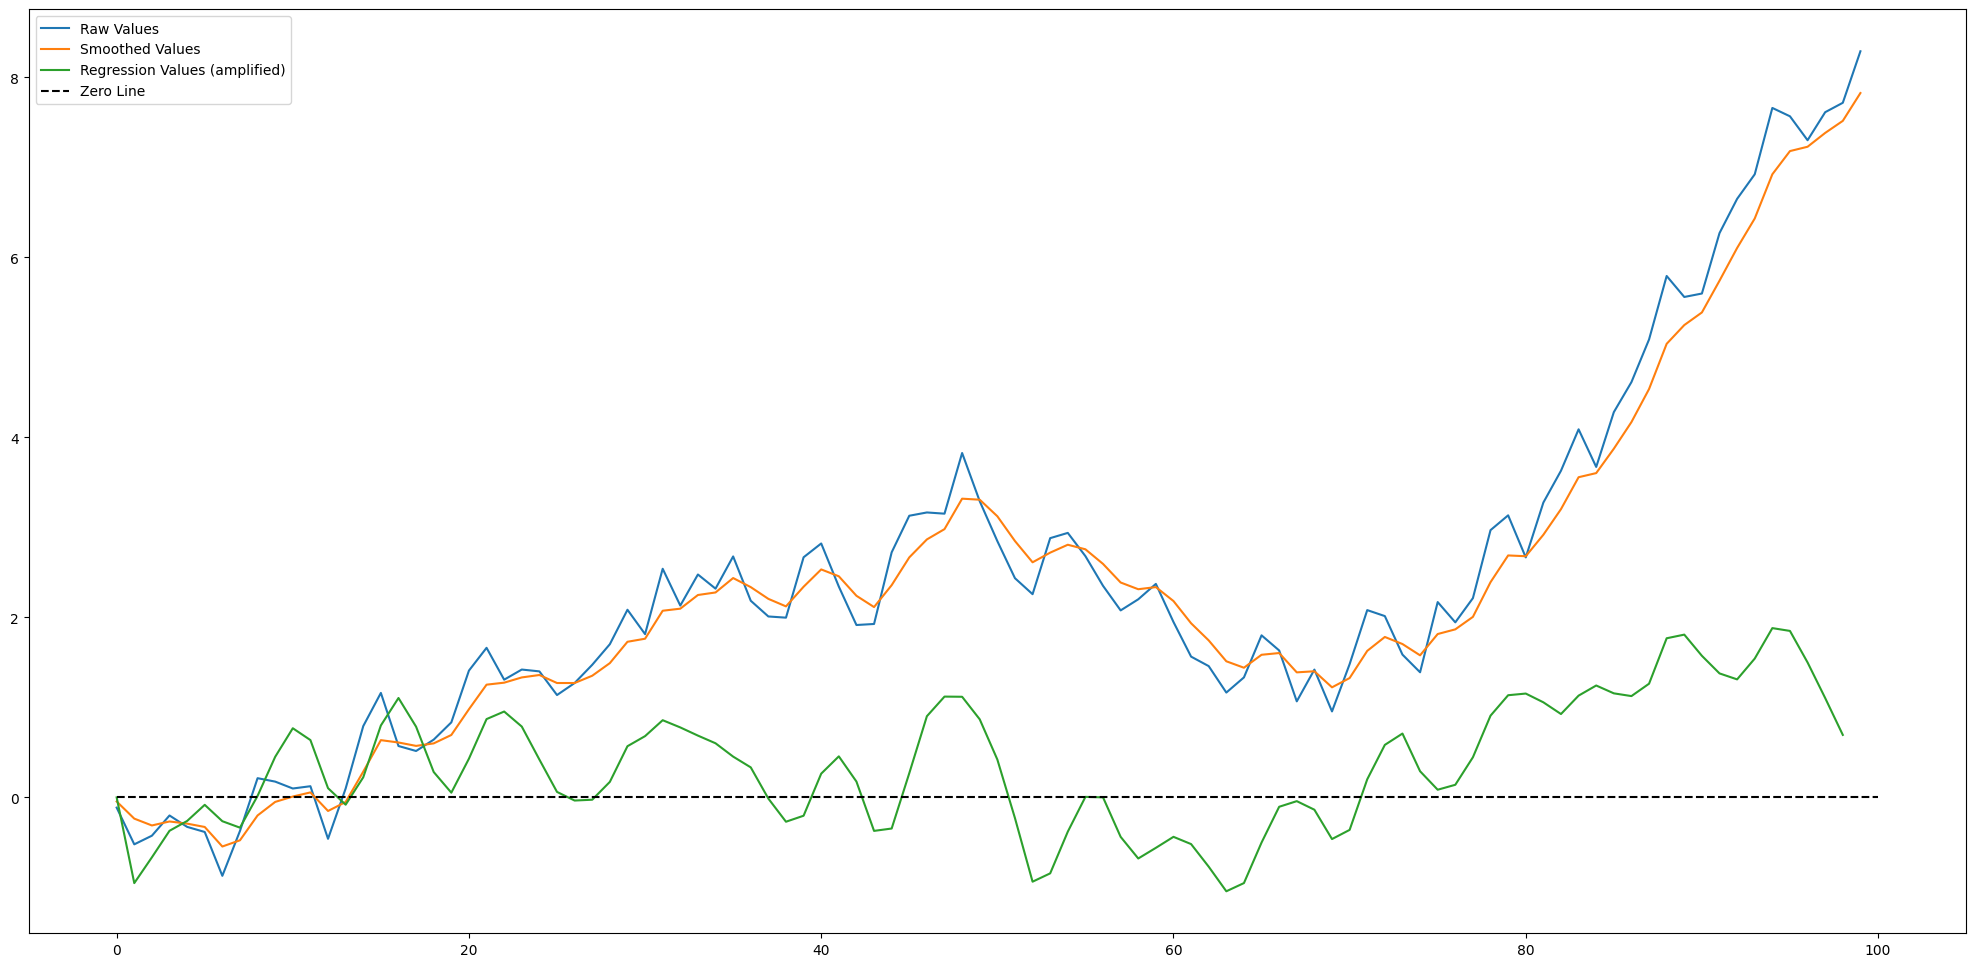

In [70]:
from matplotlib import pyplot as plt
from random import random

sample_count = 100
start = 0
delta = 0.1
turbulence_range = 0.7
ema_alpha = 0.4
regression_window_size = 5

raw_values = []
for i in range(sample_count):
    prev = raw_values[-1] if i > 0 else start
    turbulence = (turbulence_range * 2 * random()) - turbulence_range
    value = prev + delta + turbulence
    raw_values.append(value)

smoothed_values = []
for i in range(sample_count):
    raw = raw_values[i]
    prev = smoothed_values[-1] if i > 0 else start
    smoothed = (ema_alpha * raw) + ((1 - ema_alpha) * prev)
    #smoothed = (ema_alpha * raw) + ((1 - ema_alpha) * prev)
    smoothed_values.append(smoothed)

regression_values = []
for i in range(1, sample_count):
    values = smoothed_values[max(0, i - regression_window_size):i]
    n = len(values)
    x_values = list(range(i))[-n:i]

    sum_x = sum(x_values)
    sum_y = sum(values)
    sum_xy = sum(x * y for x, y in zip(x_values, values))
    sum_x2 = sum(x * x for x in x_values)

    denominator = n * sum_x2 - sum_x * sum_x
    if denominator != 0:
       slope = (n * sum_xy - sum_x * sum_y) / denominator
    else:
        slope = 0.0
    
    regression_values.append(slope * 5)


plt.plot(raw_values, label='Raw Values')
plt.plot(smoothed_values, label='Smoothed Values')
plt.plot(regression_values, label='Regression Values (amplified)')
plt.plot([0, sample_count], [0, 0], 'k--', label='Zero Line')
plt.rcParams['figure.figsize'] = [25, 12]
plt.legend()
plt.show()